<a href="https://colab.research.google.com/github/Muqeem-Ahmed/Data-Visualization-Lab/blob/main/smartphone_visualizations_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smartphone Usage & Productivity Dataset Visualizations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Smartphone_Usage_Productivity_Dataset_50000.csv')
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


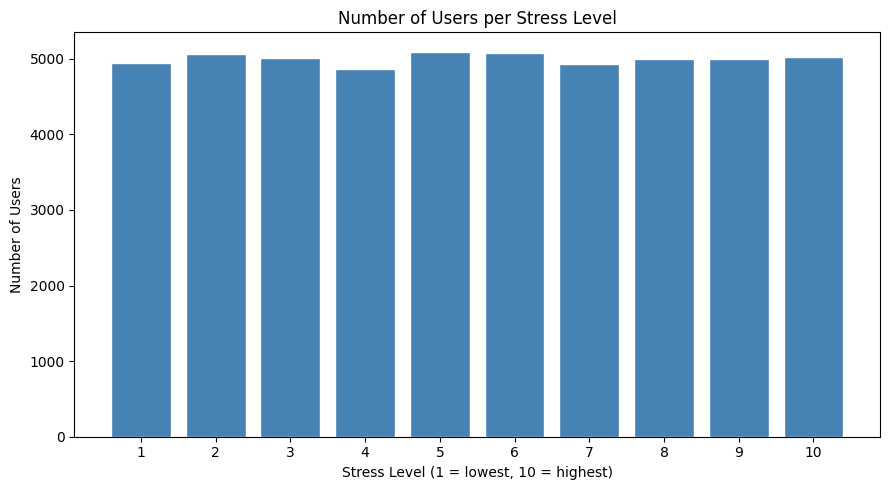

In [ ]:
# 1. Bar Chart
stress_counts = df['Stress_Level'].value_counts().sort_index()
plt.figure(figsize=(9, 5))
plt.bar(stress_counts.index, stress_counts.values, color='steelblue', edgecolor='white')
plt.title('Number of Users per Stress Level')
plt.xlabel('Stress Level (1 = lowest, 10 = highest)')
plt.ylabel('Number of Users')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

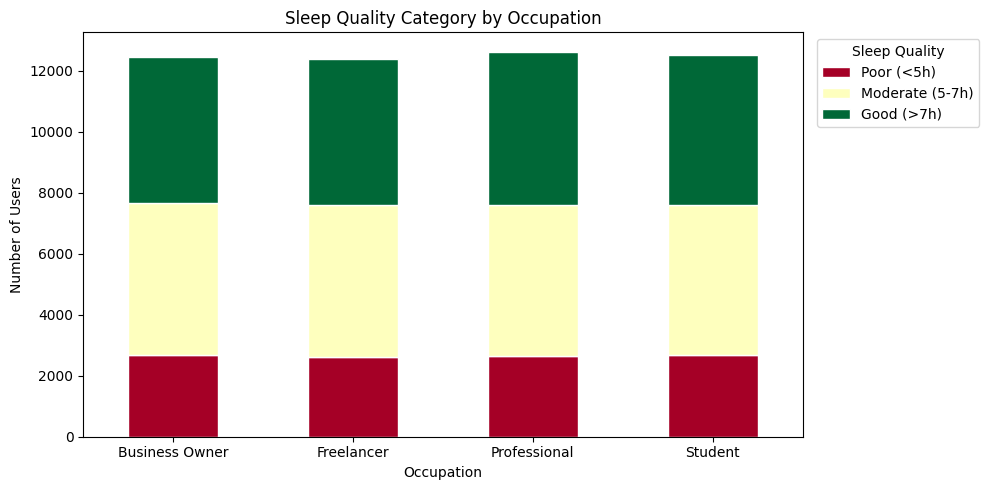

In [ ]:
# 2. Stacked Bar Chart
df['sleep_cat'] = pd.cut(df['Sleep_Hours'], bins=[0, 5, 7, 12],
                         labels=['Poor (<5h)', 'Moderate (5-7h)', 'Good (>7h)'])
ct = df.groupby(['Occupation', 'sleep_cat'], observed=True).size().unstack(fill_value=0)
ct.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='RdYlGn', edgecolor='white')
plt.title('Sleep Quality Category by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Number of Users')
plt.legend(title='Sleep Quality', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

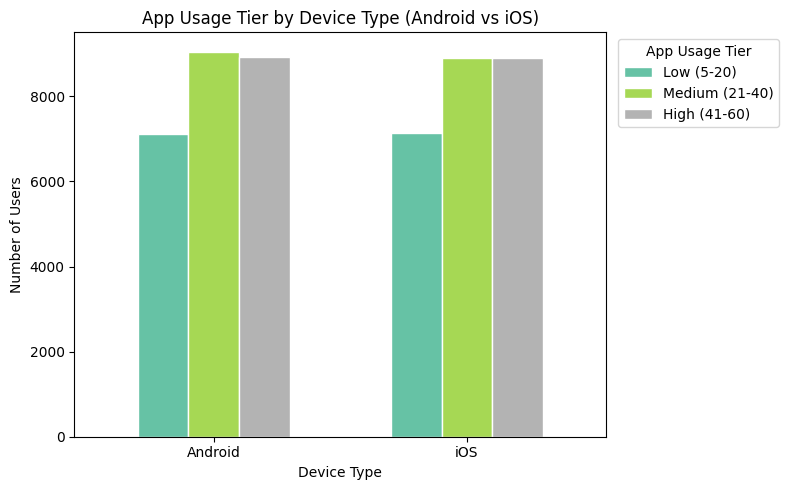

In [ ]:
# 3. Grouped Bar Chart
df['app_group'] = pd.cut(df['App_Usage_Count'], bins=[4, 20, 40, 61],
                         labels=['Low (5-20)', 'Medium (21-40)', 'High (41-60)'])
ct = df.groupby(['Device_Type', 'app_group'], observed=True).size().unstack(fill_value=0)
ct.plot(kind='bar', figsize=(8, 5), colormap='Set2', edgecolor='white', width=0.6)
plt.title('App Usage Tier by Device Type (Android vs iOS)')
plt.xlabel('Device Type')
plt.ylabel('Number of Users')
plt.legend(title='App Usage Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

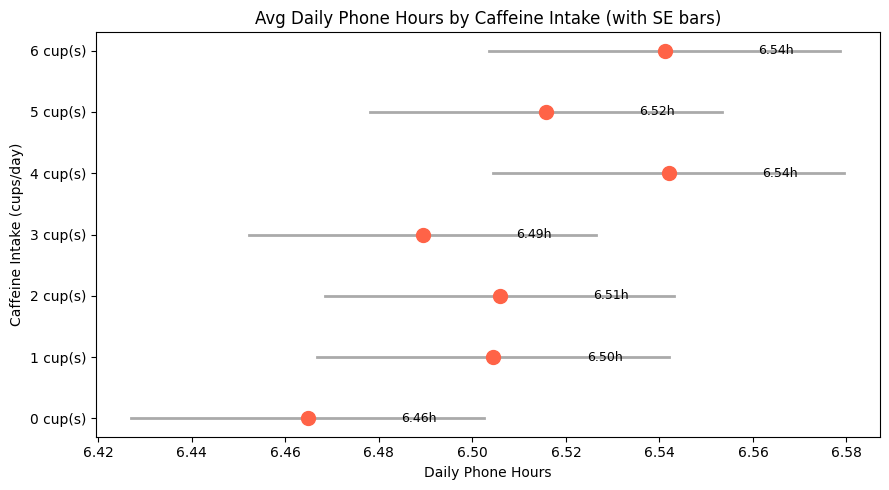

In [ ]:
# 4. Dot Plot
caffeine_stats = df.groupby('Caffeine_Intake_Cups')['Daily_Phone_Hours'].agg(['mean', 'sem'])
plt.figure(figsize=(9, 5))
for i, (idx, row) in enumerate(caffeine_stats.iterrows()):
    plt.plot([row['mean'] - row['sem'], row['mean'] + row['sem']], [i, i], color='#aaa', lw=2)
    plt.scatter(row['mean'], i, color='tomato', s=100, zorder=3)
    plt.text(row['mean'] + 0.02, i, f"{row['mean']:.2f}h", va='center', fontsize=9)
plt.yticks(range(len(caffeine_stats)), [f'{c} cup(s)' for c in caffeine_stats.index])
plt.title('Avg Daily Phone Hours by Caffeine Intake (with SE bars)')
plt.xlabel('Daily Phone Hours')
plt.ylabel('Caffeine Intake (cups/day)')
plt.tight_layout()
plt.show()

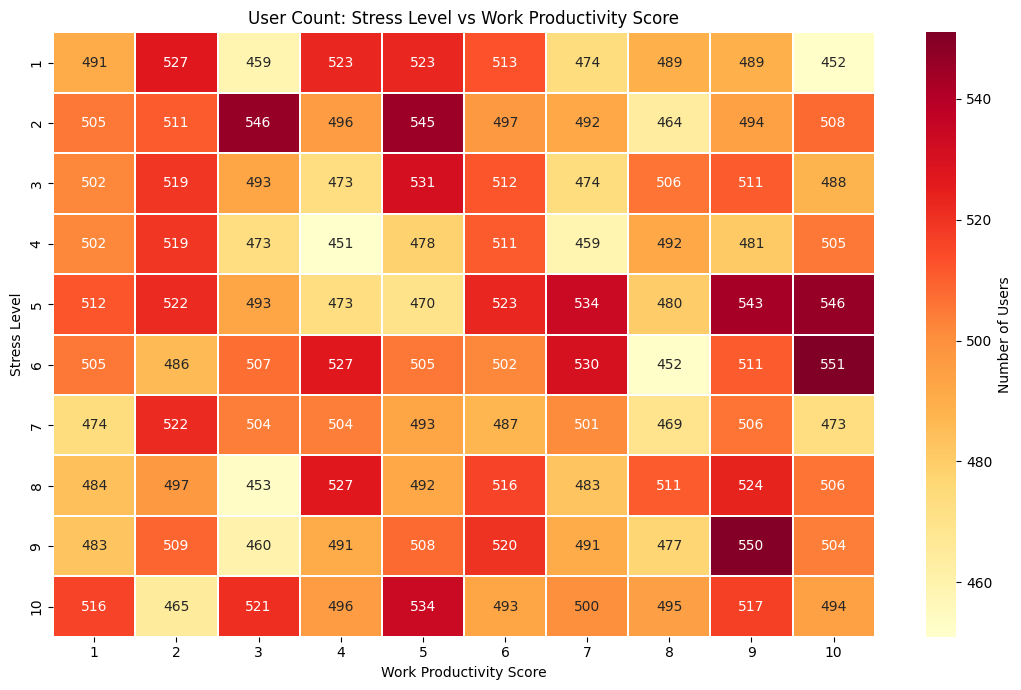

In [ ]:
# 5. Heat Map
pivot = df.groupby(['Stress_Level', 'Work_Productivity_Score']).size().unstack(fill_value=0)
plt.figure(figsize=(11, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Number of Users'})
plt.title('User Count: Stress Level vs Work Productivity Score')
plt.xlabel('Work Productivity Score')
plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()

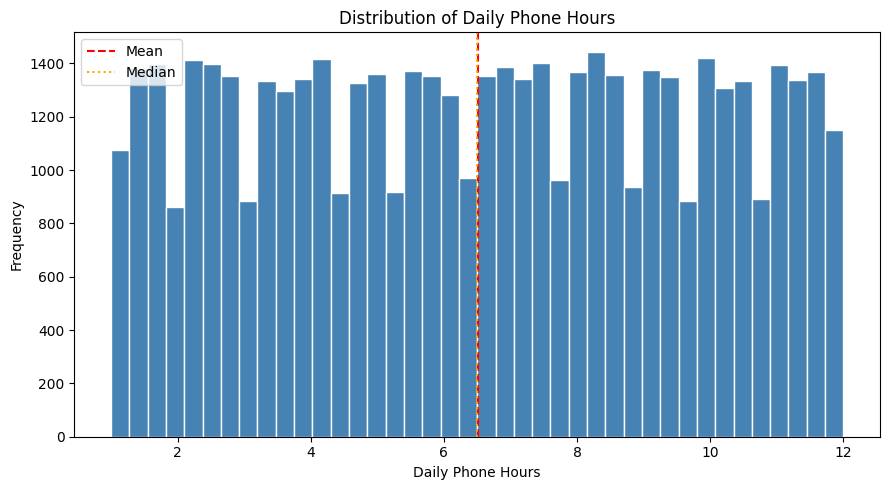

In [ ]:
# 6. Histogram
plt.figure(figsize=(9, 5))
plt.hist(df['Daily_Phone_Hours'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(df['Daily_Phone_Hours'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Daily_Phone_Hours'].median(), color='orange', linestyle=':', label='Median')
plt.title('Distribution of Daily Phone Hours')
plt.xlabel('Daily Phone Hours')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

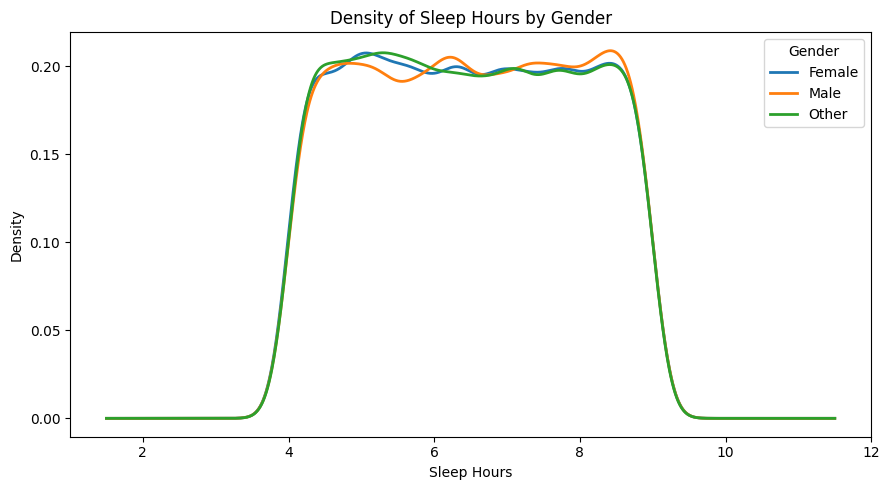

In [ ]:
# 7. Density Plot
plt.figure(figsize=(9, 5))
for gender, grp in df.groupby('Gender'):
    grp['Sleep_Hours'].plot.kde(label=gender, linewidth=2)
plt.title('Density of Sleep Hours by Gender')
plt.xlabel('Sleep Hours')
plt.ylabel('Density')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

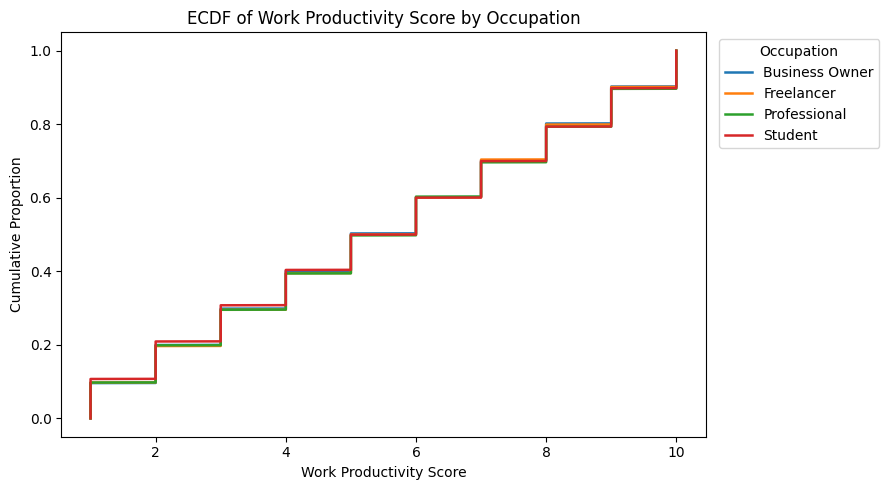

In [ ]:
# 8. ECDF
plt.figure(figsize=(9, 5))
for occ, grp in df.groupby('Occupation'):
    x = np.sort(grp['Work_Productivity_Score'])
    y = np.arange(1, len(x)+1) / len(x)
    plt.plot(x, y, label=occ, linewidth=1.8)
plt.title('ECDF of Work Productivity Score by Occupation')
plt.xlabel('Work Productivity Score')
plt.ylabel('Cumulative Proportion')
plt.legend(title='Occupation', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

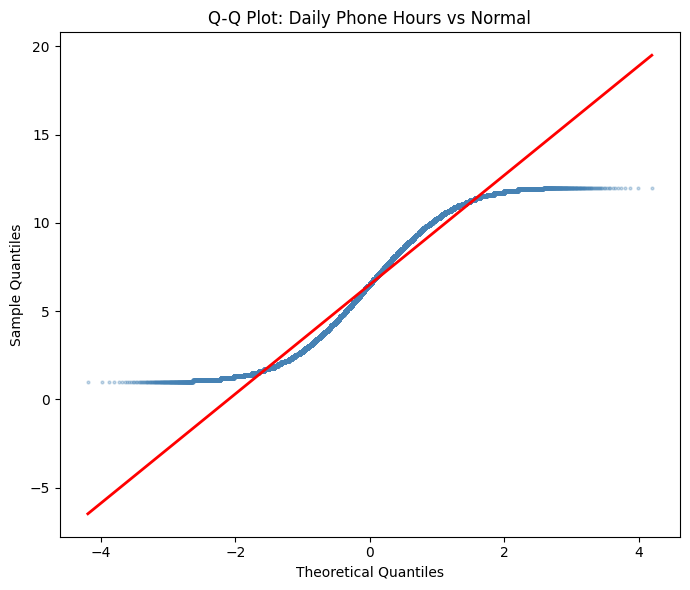

In [ ]:
# 9. Q-Q Plot
plt.figure(figsize=(7, 6))
(osm, osr), (slope, intercept, r) = stats.probplot(df['Daily_Phone_Hours'].dropna(), dist='norm')
plt.scatter(osm, osr, alpha=0.3, s=4, color='steelblue')
line_x = np.array([osm.min(), osm.max()])
plt.plot(line_x, slope * line_x + intercept, color='red', lw=2)
plt.title('Q-Q Plot: Daily Phone Hours vs Normal')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.tight_layout()
plt.show()

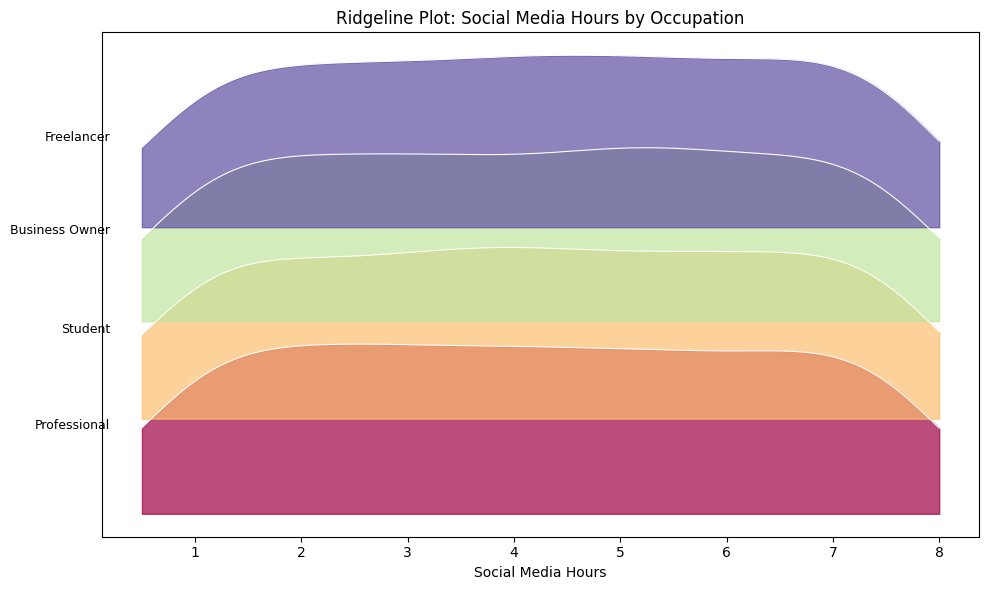

In [ ]:
# 10. Ridgeline Plot
occupations = df['Occupation'].unique()
colors = plt.cm.Spectral(np.linspace(0, 1, len(occupations)))
fig, ax = plt.subplots(figsize=(10, 6))
for i, occ in enumerate(occupations):
    subset = df[df['Occupation'] == occ]['Social_Media_Hours'].dropna()
    kde = stats.gaussian_kde(subset, bw_method=0.3)
    x_range = np.linspace(subset.min(), subset.max(), 300)
    y_vals = kde(x_range)
    y_offset = i * y_vals.max() / 1.8
    ax.fill_between(x_range, y_offset, y_offset + y_vals, alpha=0.7, color=colors[i])
    ax.plot(x_range, y_offset + y_vals, color='white', lw=0.8)
    ax.text(x_range[0] - 0.3, y_offset + y_vals.max()/2, occ, ha='right', fontsize=9)
ax.set_yticks([])
ax.set_title('Ridgeline Plot: Social Media Hours by Occupation')
ax.set_xlabel('Social Media Hours')
plt.tight_layout()
plt.show()

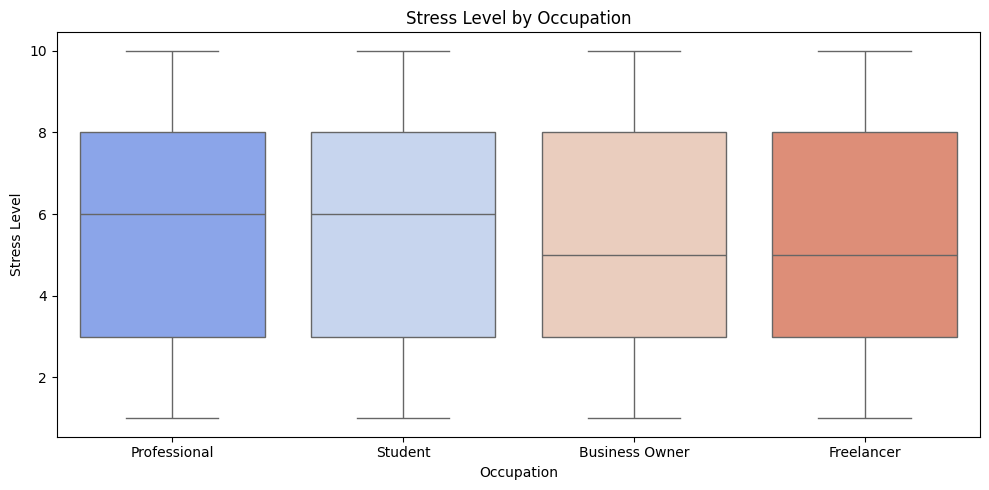

In [ ]:
# 11. Box Plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Occupation', y='Stress_Level', palette='coolwarm')
plt.title('Stress Level by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()

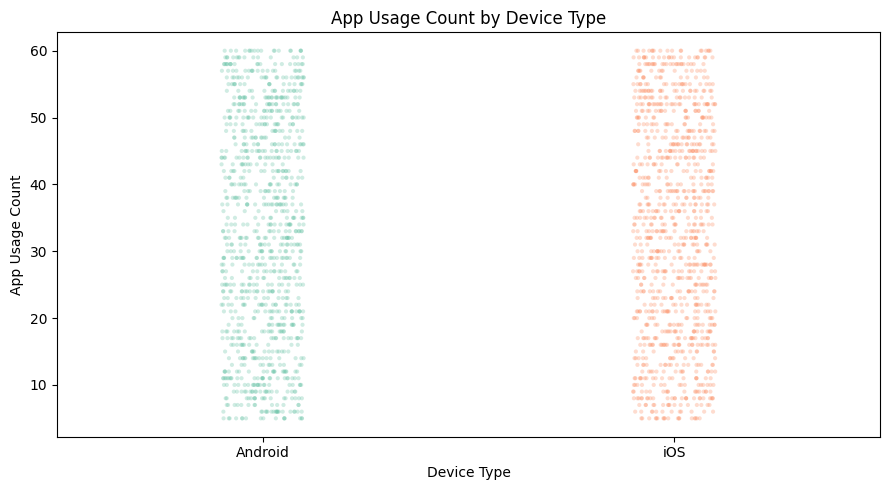

In [ ]:
# 12. Strip Chart
sample = df.sample(2000, random_state=42)
plt.figure(figsize=(9, 5))
sns.stripplot(data=sample, x='Device_Type', y='App_Usage_Count', jitter=True, alpha=0.3, palette='Set2', size=3)
plt.title('App Usage Count by Device Type')
plt.xlabel('Device Type')
plt.ylabel('App Usage Count')
plt.tight_layout()
plt.show()

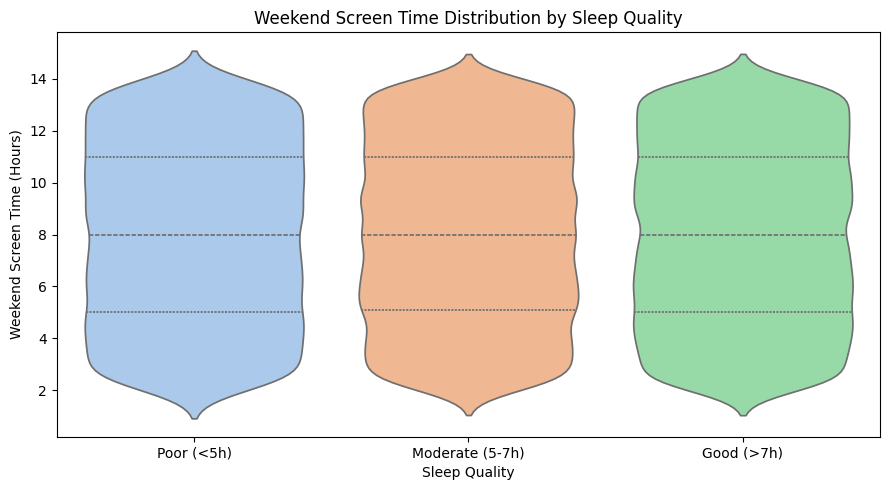

In [ ]:
# 13. Violin Plot
df['sleep_cat'] = pd.cut(df['Sleep_Hours'], bins=[0, 5, 7, 12],
                         labels=['Poor (<5h)', 'Moderate (5-7h)', 'Good (>7h)'])
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='sleep_cat', y='Weekend_Screen_Time_Hours',
               palette='pastel', inner='quartile', order=['Poor (<5h)', 'Moderate (5-7h)', 'Good (>7h)'])
plt.title('Weekend Screen Time Distribution by Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Weekend Screen Time (Hours)')
plt.tight_layout()
plt.show()

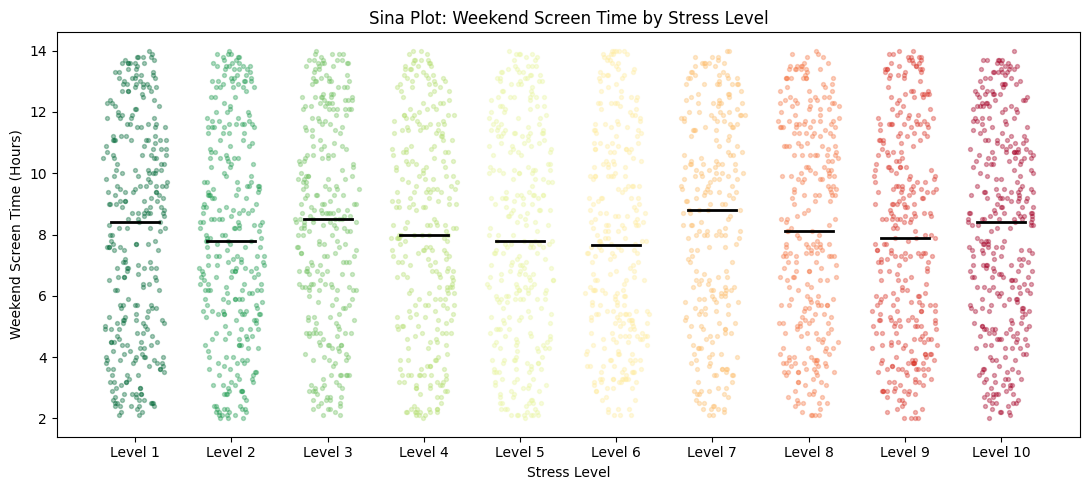

In [ ]:
# 14. Sina Plot
sample = df.sample(3000, random_state=0)
stress_levels = sorted(sample['Stress_Level'].unique())
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(stress_levels)))
plt.figure(figsize=(11, 5))
np.random.seed(42)
for i, level in enumerate(stress_levels):
    sub = sample[sample['Stress_Level'] == level]['Weekend_Screen_Time_Hours'].values
    kde = stats.gaussian_kde(sub, bw_method=0.4)
    densities = kde(sub)
    jitter = (densities / densities.max()) * 0.35 * (np.random.rand(len(sub)) * 2 - 1)
    plt.scatter(i + jitter, sub, color=colors[i], alpha=0.35, s=8)
    plt.plot([i - 0.25, i + 0.25], [np.median(sub)]*2, color='black', lw=2)
plt.xticks(range(len(stress_levels)), [f'Level {l}' for l in stress_levels])
plt.title('Sina Plot: Weekend Screen Time by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Weekend Screen Time (Hours)')
plt.tight_layout()
plt.show()

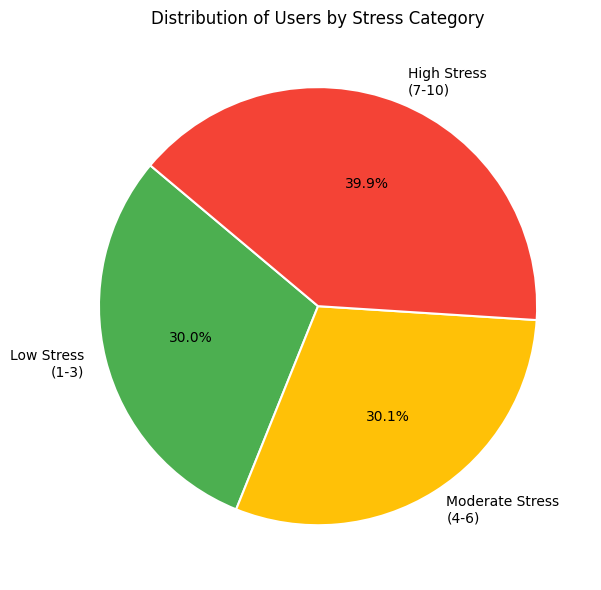

In [ ]:
# 15. Pie Chart
df['stress_cat'] = pd.cut(df['Stress_Level'], bins=[0, 3, 6, 10],
                          labels=['Low Stress\n(1-3)', 'Moderate Stress\n(4-6)', 'High Stress\n(7-10)'])
counts = df['stress_cat'].value_counts().sort_index()
plt.figure(figsize=(7, 6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#4CAF50', '#FFC107', '#F44336'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Distribution of Users by Stress Category')
plt.tight_layout()
plt.show()